In [1]:
import sklearn
from sklearn.datasets import make_circles
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer
from tqdm.auto import tqdm

import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from helper_functions import plot_predictions, plot_decision_boundary
from helper_functions import accuracy_fn

import zipfile
import requests
from pathlib import Path
import os
import random
from PIL import Image

print(torch.__version__)
print(torchvision.__version__)

1.11.0
0.12.0


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
!nvidia-smi

Wed Aug 20 19:56:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.42                 Driver Version: 572.42         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   42C    P8              4W /   50W |     834MiB /   4096MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
data_path = Path("../data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

if image_path.is_dir():
    print(f"{image_path} directory already exists.")

else:
    print(f"{image_path} does not exist, creating one now...")
    image_path.mkdir(parents = True, exist_ok = True)
    

..\data\pizza_steak_sushi_20_percent directory already exists.


In [5]:
'''with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("http://github.com....zip")
    print("Downloading Data")
    f.write(request.content)

with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping data...")
    zip_ref.extractall(image_path)
''' 

'with open(data_path / "pizza_steak_sushi.zip", "wb") as f:\n    request = requests.get("http://github.com....zip")\n    print("Downloading Data")\n    f.write(request.content)\n\nwith zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:\n    print("Unzipping data...")\n    zip_ref.extractall(image_path)\n'

In [6]:
def walkthrough(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
walkthrough(image_path)

There are 2 directories and 0 images in '..\data\pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in '..\data\pizza_steak_sushi_20_percent\test'.
There are 0 directories and 46 images in '..\data\pizza_steak_sushi_20_percent\test\pizza'.
There are 0 directories and 58 images in '..\data\pizza_steak_sushi_20_percent\test\steak'.
There are 0 directories and 46 images in '..\data\pizza_steak_sushi_20_percent\test\sushi'.
There are 3 directories and 0 images in '..\data\pizza_steak_sushi_20_percent\train'.
There are 0 directories and 154 images in '..\data\pizza_steak_sushi_20_percent\train\pizza'.
There are 0 directories and 146 images in '..\data\pizza_steak_sushi_20_percent\train\steak'.
There are 0 directories and 150 images in '..\data\pizza_steak_sushi_20_percent\train\sushi'.


In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('../data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('../data/pizza_steak_sushi_20_percent/test'))

..\data\pizza_steak_sushi_20_percent\test\sushi\2948087.jpg
sushi
Random image path: ..\data\pizza_steak_sushi_20_percent\test\sushi\2948087.jpg
Image Class: sushi
Image Height: 512, Width: 512


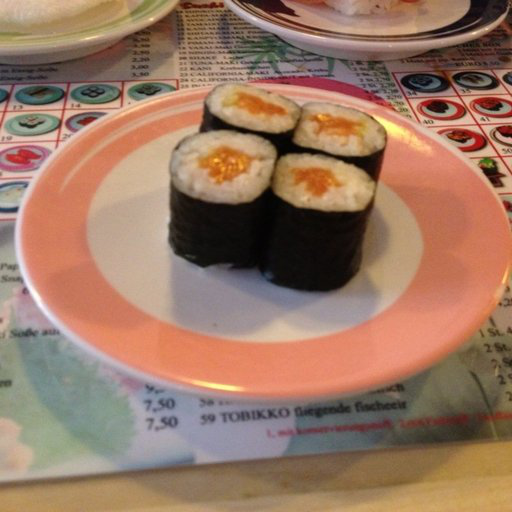

In [8]:
#random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)
print(random_image_path)

image_class = random_image_path.parent.stem
print(image_class)

img = Image.open(random_image_path)
print(f"Random image path: {random_image_path}")
print(f"Image Class: {image_class}")
print(f"Image Height: {img.height}, Width: {img.width}")
img

(-0.5, 511.5, 511.5, -0.5)

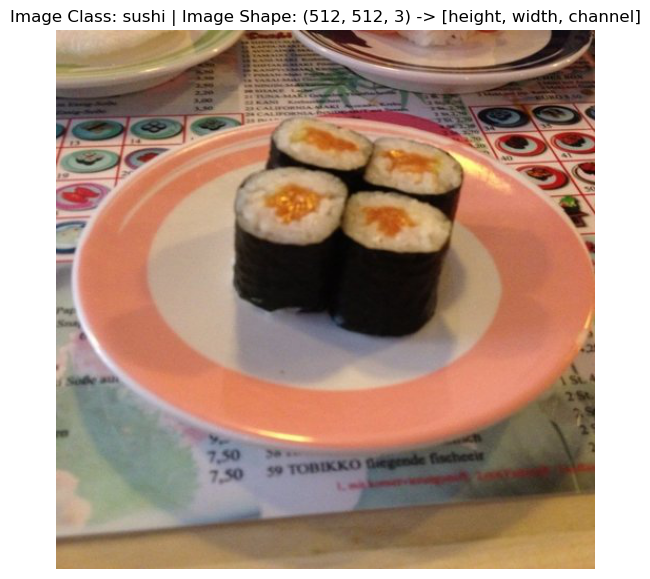

In [9]:
img_as_array = np.asarray(img)

plt.figure(figsize = (10,7))
plt.imshow(img_as_array)
plt.title(f"Image Class: {image_class} | Image Shape: {img_as_array.shape} -> [height, width, channel]")
plt.axis(False)

In [10]:
img_as_array

array([[[215, 187, 166],
        [213, 185, 164],
        [210, 182, 161],
        ...,
        [ 92,  64,  52],
        [ 80,  48,  33],
        [ 90,  57,  40]],

       [[217, 189, 167],
        [215, 187, 165],
        [212, 184, 162],
        ...,
        [ 94,  66,  54],
        [ 85,  53,  38],
        [ 81,  50,  32]],

       [[221, 190, 169],
        [219, 188, 167],
        [216, 185, 164],
        ...,
        [116,  88,  76],
        [110,  81,  65],
        [ 82,  51,  33]],

       ...,

       [[178, 142,  84],
        [178, 142,  84],
        [179, 140,  83],
        ...,
        [201, 153,  89],
        [200, 152,  90],
        [200, 152,  90]],

       [[177, 141,  83],
        [177, 141,  83],
        [180, 141,  84],
        ...,
        [197, 149,  85],
        [196, 148,  86],
        [195, 147,  85]],

       [[176, 140,  82],
        [177, 141,  83],
        [181, 142,  85],
        ...,
        [197, 149,  85],
        [195, 147,  83],
        [194, 146,  84]]

In [11]:
data_transform = transforms.Compose([
    transforms.Resize(size = (64,64)),
    transforms.RandomHorizontalFlip(p=.08),
    transforms.ToTensor()
])

In [12]:
data_transform(img)

tensor([[[0.8431, 0.8392, 0.8314,  ..., 0.1412, 0.1373, 0.2549],
         [0.7922, 0.7843, 0.8000,  ..., 0.1686, 0.2235, 0.2941],
         [0.6863, 0.6863, 0.7098,  ..., 0.3176, 0.4902, 0.3216],
         ...,
         [0.6235, 0.6392, 0.6471,  ..., 0.7725, 0.7765, 0.7843],
         [0.7098, 0.7098, 0.7137,  ..., 0.7922, 0.7843, 0.7843],
         [0.7098, 0.7216, 0.7176,  ..., 0.7961, 0.7882, 0.7922]],

        [[0.7294, 0.7216, 0.7216,  ..., 0.1059, 0.0980, 0.1804],
         [0.6941, 0.6902, 0.7059,  ..., 0.1294, 0.1608, 0.2235],
         [0.6157, 0.6196, 0.6431,  ..., 0.2549, 0.3647, 0.2118],
         ...,
         [0.4902, 0.5137, 0.5216,  ..., 0.6039, 0.6157, 0.6157],
         [0.5647, 0.5765, 0.5765,  ..., 0.6196, 0.6196, 0.6196],
         [0.5608, 0.5647, 0.5686,  ..., 0.6118, 0.6078, 0.6078]],

        [[0.6392, 0.6353, 0.6314,  ..., 0.1098, 0.1020, 0.1569],
         [0.5843, 0.5961, 0.6235,  ..., 0.1294, 0.1529, 0.1882],
         [0.4863, 0.5059, 0.5451,  ..., 0.2196, 0.2980, 0.

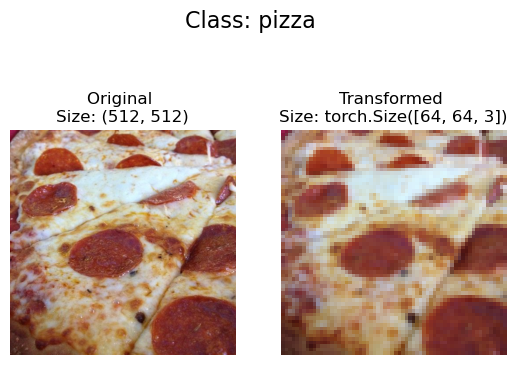

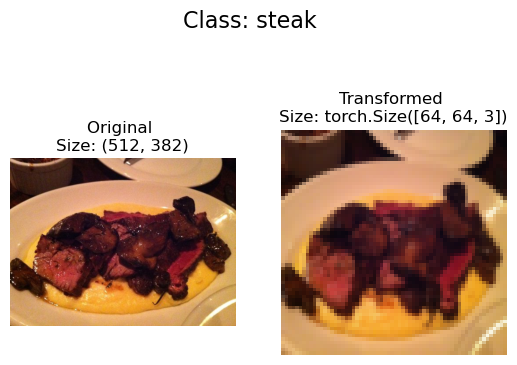

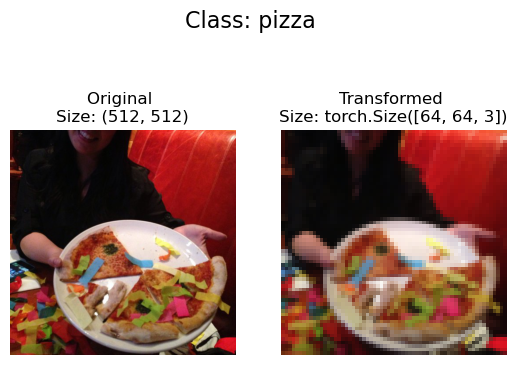

In [13]:
def plot_transformed_images(image_paths: list, transform, n=3, seed = None):
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k = n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax = plt.subplots(nrows = 1, ncols = 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis(False)

            transformed_image = transform(f).permute(1,2,0) # CHANGE SHAPE FOR matplotlib (C,H,W) -> (H,W,C)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize = 16)

plot_transformed_images(image_paths = image_path_list, transform = data_transform, n = 3, seed = None)


In [14]:
 #train_data[0]

In [15]:
train_data = datasets.ImageFolder(root = train_dir, transform = data_transform, target_transform = None)
test_data = datasets.ImageFolder(root = test_dir, transform = data_transform)

train_data

Dataset ImageFolder
    Number of datapoints: 450
    Root location: ..\data\pizza_steak_sushi_20_percent\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=None)
               RandomHorizontalFlip(p=0.08)
               ToTensor()
           )

In [16]:
train_data[0]

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0863],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0706],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0196,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [17]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image Tensor: {img}\nLabel: {label}\nImage Shape: {img.shape}")

Image Tensor: tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0863],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0706],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0196,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

In [18]:
img_permute = img.permute(1,2,0)
img_permute.shape

torch.Size([64, 64, 3])

(-0.5, 63.5, 63.5, -0.5)

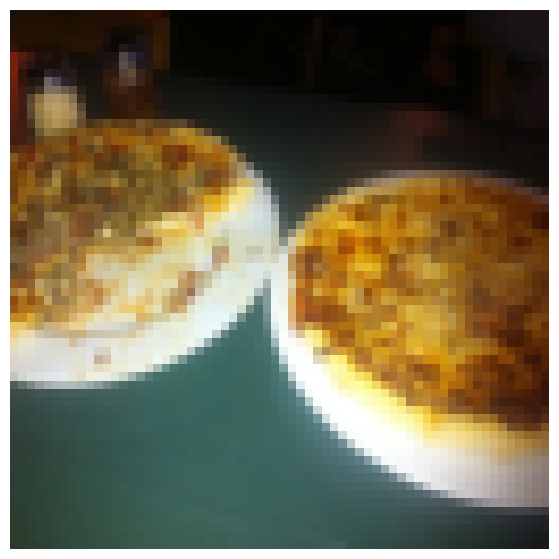

In [19]:
plt.figure(figsize = (10,7))
plt.imshow(img_permute)
plt.axis(False)

In [20]:
class_names = train_data.classes
class_dict = train_data.class_to_idx

class_names, class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [21]:
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data, batch_size = BATCH_SIZE, num_workers = 1, shuffle = True)
test_dataloader = DataLoader(dataset = test_data, batch_size = BATCH_SIZE, num_workers = 1, shuffle = False)

train_dataloader

In [22]:
import os
os.cpu_count()

8

In [23]:
len(train_dataloader), len(train_data)

(15, 450)

In [24]:
img, label = next(iter(train_dataloader))
img.shape, label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [25]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size = 3, stride = 1, padding =1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 16 * 16, output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        #print(x.shape)
        x = self.conv_block_2(x)
        #print(x.shape)
        x = self.classifier(x)
        #print(x.shape)
        return x

In [26]:
torch.manual_seed(42)
model_0 = TinyVGG(3,10,len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [27]:
img, label = next(iter(train_dataloader))
img.shape, label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [28]:
model_0(img.to(device))

tensor([[0.0649, 0.0630, 0.0392],
        [0.0636, 0.0605, 0.0360],
        [0.0606, 0.0593, 0.0380],
        [0.0636, 0.0603, 0.0367],
        [0.0610, 0.0599, 0.0372],
        [0.0636, 0.0641, 0.0386],
        [0.0637, 0.0614, 0.0419],
        [0.0666, 0.0663, 0.0388],
        [0.0674, 0.0664, 0.0396],
        [0.0642, 0.0620, 0.0386],
        [0.0620, 0.0666, 0.0351],
        [0.0680, 0.0646, 0.0431],
        [0.0633, 0.0595, 0.0373],
        [0.0678, 0.0621, 0.0348],
        [0.0608, 0.0626, 0.0375],
        [0.0694, 0.0657, 0.0420],
        [0.0682, 0.0646, 0.0400],
        [0.0678, 0.0677, 0.0403],
        [0.0624, 0.0591, 0.0388],
        [0.0603, 0.0590, 0.0373],
        [0.0668, 0.0636, 0.0393],
        [0.0661, 0.0639, 0.0410],
        [0.0677, 0.0618, 0.0422],
        [0.0605, 0.0605, 0.0399],
        [0.0603, 0.0636, 0.0377],
        [0.0660, 0.0590, 0.0398],
        [0.0536, 0.0627, 0.0372],
        [0.0631, 0.0572, 0.0366],
        [0.0693, 0.0675, 0.0413],
        [0.068

In [78]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, device = device):
    model.train()

    train_loss, train_acc = 0,0

    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc

In [30]:
#23:23:23

In [31]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module,  device = device):
    model.eval()

    test_loss, test_acc = 0,0

    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc
    

In [80]:
def run(model: torch.nn.Module, 
        train_dataloader: torch.utils.data.DataLoader, 
        test_dataloader: torch.utils.data.DataLoader, 
        optimizer: torch.optim.Optimizer, 
        loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
        epochs: int = 5, 
        device = device):

    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model = model, dataloader = train_dataloader, loss_fn = loss_fn, optimizer = optimizer, device = device)
        test_loss, test_acc = test_step(model = model, dataloader = test_dataloader, loss_fn = loss_fn, device = device)

        print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.4f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc * 100:.4f}%")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

In [102]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 20

model_0 = TinyVGG(input_shape = 3, hidden_units = 10, output_shape = len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(), lr = 0.01)

start_time = timer()

model_0_results = run(model = model_0, train_dataloader = train_dataloader, test_dataloader = test_dataloader, optimizer = optimizer, loss_fn = loss_fn, epochs = NUM_EPOCHS, device = device)

end_time = timer()

print(f"Total Training Time: {end_time - start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.1348 | Train Acc: 31.2500% | Test Loss: 1.0987 | Test Acc: 35.0000%
Epoch: 1 | Train Loss: 1.0994 | Train Acc: 29.7917% | Test Loss: 1.0996 | Test Acc: 28.7500%
Epoch: 2 | Train Loss: 1.0986 | Train Acc: 32.5000% | Test Loss: 1.0985 | Test Acc: 36.2500%
Epoch: 3 | Train Loss: 1.0994 | Train Acc: 31.2500% | Test Loss: 1.0992 | Test Acc: 28.7500%
Epoch: 4 | Train Loss: 1.0992 | Train Acc: 29.7917% | Test Loss: 1.0985 | Test Acc: 36.2500%
Epoch: 5 | Train Loss: 1.0980 | Train Acc: 34.3750% | Test Loss: 1.1007 | Test Acc: 28.7500%
Epoch: 6 | Train Loss: 1.1018 | Train Acc: 32.0833% | Test Loss: 1.1040 | Test Acc: 28.7500%
Epoch: 7 | Train Loss: 1.0959 | Train Acc: 38.3333% | Test Loss: 1.1026 | Test Acc: 28.7500%
Epoch: 8 | Train Loss: 1.0945 | Train Acc: 38.3333% | Test Loss: 1.1054 | Test Acc: 28.7500%
Epoch: 9 | Train Loss: 1.0984 | Train Acc: 35.2083% | Test Loss: 1.1076 | Test Acc: 28.7500%
Epoch: 10 | Train Loss: 1.0981 | Train Acc: 35.2083% | Test Loss: 1.10

In [103]:
model_0_results

{'train_loss': [1.134809954961141,
  1.0994215170542398,
  1.0985896190007527,
  1.0993630329767863,
  1.0991838773091633,
  1.0979694207509358,
  1.1017795006434123,
  1.0958728472391763,
  1.094513996442159,
  1.0983902931213378,
  1.0980929533640544,
  1.1002880970637003,
  1.0970160325368246,
  1.095760170618693,
  1.0981125434239705,
  1.099731691678365,
  1.0989320516586303,
  1.0951847553253173,
  1.102135149637858,
  1.0983993848164877],
 'train_acc': [0.3125,
  0.29791666666666666,
  0.325,
  0.3125,
  0.29791666666666666,
  0.34375,
  0.32083333333333336,
  0.38333333333333336,
  0.38333333333333336,
  0.35208333333333336,
  0.35208333333333336,
  0.32083333333333336,
  0.31666666666666665,
  0.38333333333333336,
  0.35208333333333336,
  0.35208333333333336,
  0.35208333333333336,
  0.38333333333333336,
  0.32083333333333336,
  0.35208333333333336],
 'test_loss': [1.0987431287765503,
  1.099608588218689,
  1.0985142707824707,
  1.0992225885391236,
  1.0985377550125122,
  1.10

In [104]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [105]:
from typing import Dict, List

def plot_loss_curves(results: Dict[str, List[float]]):
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]

    train_acc = results["train_acc"]
    test_acc = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15,7))

    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label= "Training Loss")
    plt.plot(epochs, test_loss, label = "Testing Loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label= "Training Acc")
    plt.plot(epochs, test_acc, label = "Testing Acc")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

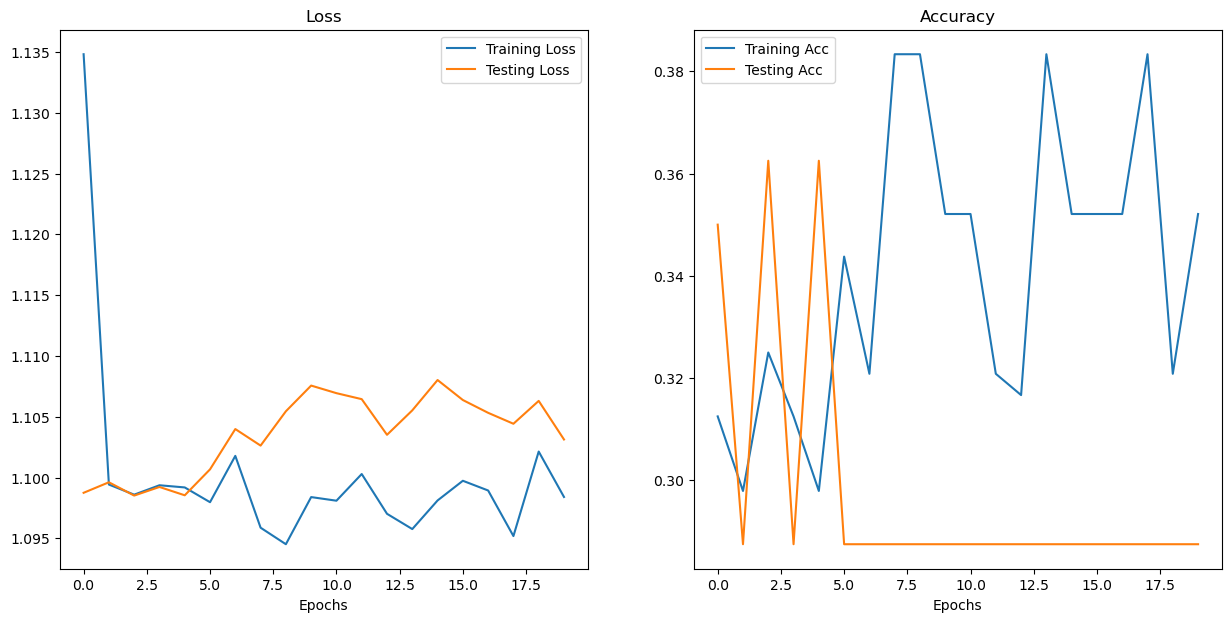

In [106]:
plot_loss_curves(model_0_results)

In [38]:
#1:00:00:00

In [132]:
import requests

custom_image_path = data_path / "04-pizza-dad.jpeg"

if not custom_image_path.is_file():
    url = "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg"
    with open(custom_image_path, "wb") as f:
        print(f"Downloading {custom_image_path}...")
        response = requests.get(url)
        f.write(response.content)
else:
    print("Image Already Exists")


In [134]:
import torchvision

custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
custom_image_uint8

tensor([[[154, 175, 181,  ...,  21,  18,  14],
         [146, 167, 180,  ...,  21,  18,  15],
         [124, 146, 171,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 189, 193,  ...,  22,  19,  15],
         [163, 181, 194,  ...,  22,  19,  16],
         [141, 163, 185,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 106, 104, 102],
         [ 47,  38,  24,  ..., 108, 105, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[117, 138, 145,  ...,  17,  14,  10],
         [109, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  54,  52,  50],
         [ 27,  18,   4,  ...,  50,  47,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

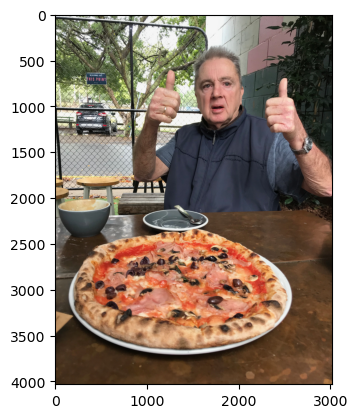

In [136]:
plt.imshow(custom_image_uint8.permute(1,2,0))

In [138]:
print(f"Custom image tensor: \n {custom_image_uint8}")

print(f"Image Shape: {custom_image_uint8.shape}")

Custom image tensor: 
 tensor([[[154, 175, 181,  ...,  21,  18,  14],
         [146, 167, 180,  ...,  21,  18,  15],
         [124, 146, 171,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 189, 193,  ...,  22,  19,  15],
         [163, 181, 194,  ...,  22,  19,  16],
         [141, 163, 185,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 106, 104, 102],
         [ 47,  38,  24,  ..., 108, 105, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[117, 138, 145,  ...,  17,  14,  10],
         [109, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  54,  52,  50],
         [ 27,  18,   4,  ...,  50,  47,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)
Image Shape: torch.Size([3, 4032, 3024])


In [146]:
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255
custom_image.dtype

torch.float32

In [148]:
custom_image_transform = transforms.Compose([transforms.Resize(size = (64,64)),
                                             
                                            ])
custom_image_transformed = custom_image_transform(custom_image)
print(custom_image_transformed.shape)

torch.Size([3, 64, 64])


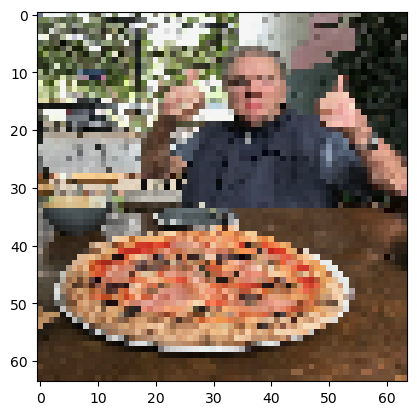

In [154]:
plt.imshow(custom_image_transformed.permute(1,2,0))

In [164]:
model_0.eval()

with torch.inference_mode():
    custom_image_pred = model_0(custom_image_transformed.unsqueeze(0).to(device))
custom_image_pred

tensor([[ 0.0626, -0.0198, -0.0189]], device='cuda:0')

In [166]:
cutom_image_pred_probs = torch.softmax(cutom_image_pred, dim=1)
cutom_image_pred_probs

tensor([[0.3518, 0.3240, 0.3242]], device='cuda:0')

In [168]:
cutom_image_pred_labels = torch.argmax(cutom_image_pred_probs, dim=1)
cutom_image_pred_labels

tensor([0], device='cuda:0')

In [170]:
class_names[cutom_image_pred_labels]

'pizza'

In [188]:
def pred_plot_image(model: torch.nn.Module,
                    image_path: str,
                    class_names: List[str] = None,
                    transform = None,
                    device = device):
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)
    target_image = target_image / 255

    if transform:
        target_image = transform(target_image)

    model.to(device)

    model.eval()
    with torch.inference_mode():
        target_image = target_image.unsqueeze(0)
        target_image_pred = model(target_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim = 1)
    target_image_pred_labels = torch.argmax(target_image_pred_probs, dim = 1)

    plt.imshow(target_image.squeeze().permute(1,2,0))
    if class_names:
        title = f"Pred: {class_names[target_image_pred_labels.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"

    plt.title(title)
    plt.axis(False)

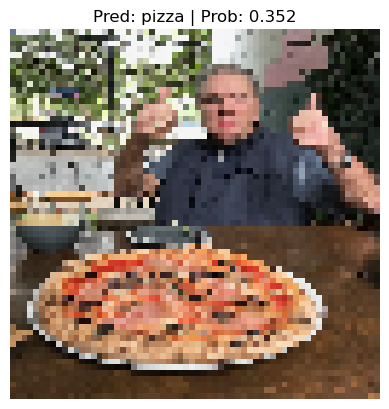

In [194]:
pred_plot_image(model_0, image_path = custom_image_path, class_names = class_names, transform = custom_image_transform, device = device)